In [1]:
from google.colab import files
import pandas as pd

# Step 1: Upload the file
uploaded = files.upload()



Saving StudentsPerformance.csv to StudentsPerformance.csv


In [3]:

# Step 2: Read the uploaded CSV file (replace with your actual filename if needed)
df = pd.read_csv('StudentsPerformance.csv')

# Step 3: Preview the dataset
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
print("Data Types:", df.dtypes)


Data Types: gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

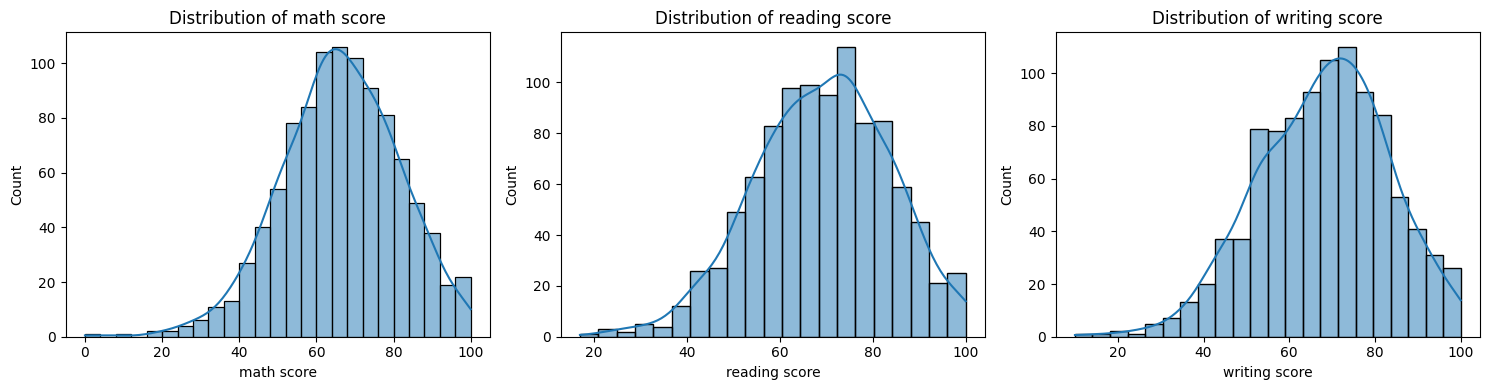

In [6]:
# Plot histograms
numeric_cols = ['math score', 'reading score', 'writing score']

plt.figure(figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


Z-Score Outlier Detection

🧮 Mathematical Formula:

𝑍
=
𝑥
−
𝜇
𝜎

Z=
σ
x−μ
​




In [7]:
from scipy.stats import zscore

# Calculate Z-scores
df_z = df[numeric_cols].apply(zscore)

# Identify outliers (threshold = 3)
z_thresh = 3
outliers_z = (df_z.abs() > z_thresh)

# Add outlier flags to original DataFrame
for col in numeric_cols:
    df[f'{col}_outlier_z'] = outliers_z[col]

# Print results
print("\nZ-Score Outliers:\n", df[[f'{col}_outlier_z' for col in numeric_cols]].sum())



Z-Score Outliers:
 math score_outlier_z       4
reading score_outlier_z    4
writing score_outlier_z    4
dtype: int64


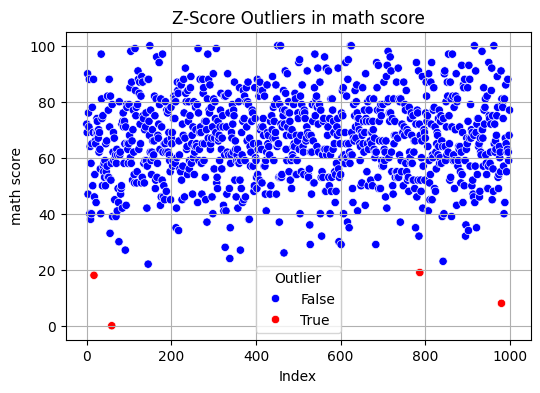

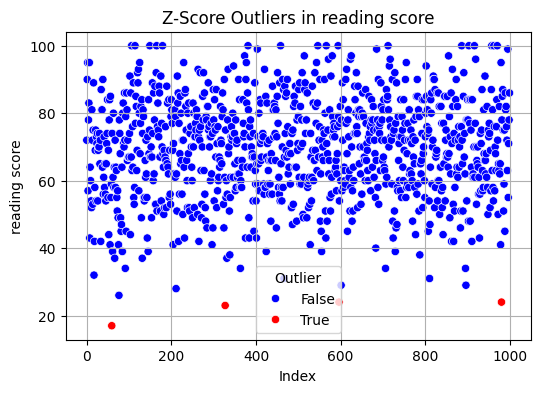

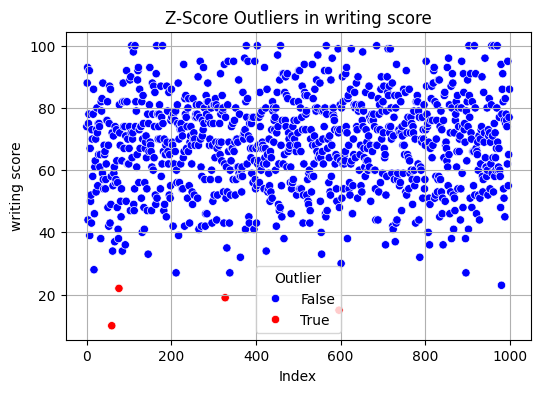

In [8]:
# Visualize outliers for each column
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df.index, y=df[col], hue=df[f'{col}_outlier_z'], palette={True: 'red', False: 'blue'})
    plt.title(f'Z-Score Outliers in {col}')
    plt.xlabel("Index")
    plt.ylabel(col)
    plt.legend(title='Outlier')
    plt.grid()
    plt.show()


 IQR Outlier Detection

🧮 Formula:

IQR
=
𝑄
3
−
𝑄
1

Lower Bound
=
𝑄
1
−
1.5
×
IQR

Upper Bound
=
𝑄
3
+
1.5
×
IQR



In [9]:
# IQR method
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[f'{col}_outlier_iqr'] = df[col].apply(lambda x: x < lower or x > upper)

# Print outlier counts
print("\nIQR Outliers:\n", df[[f'{col}_outlier_iqr' for col in numeric_cols]].sum())



IQR Outliers:
 math score_outlier_iqr       8
reading score_outlier_iqr    6
writing score_outlier_iqr    5
dtype: int64


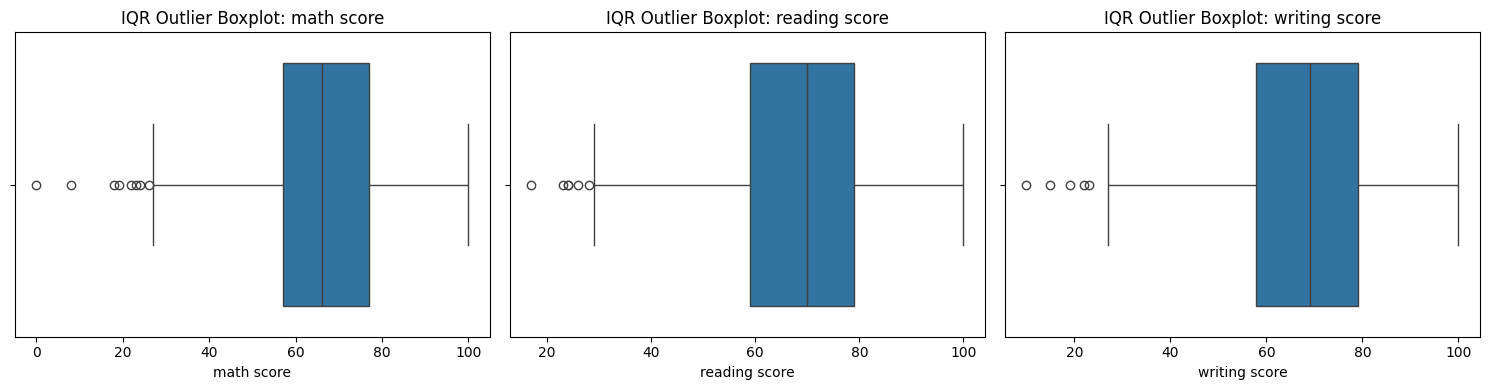

In [10]:
# Boxplots to show IQR-based outliers
plt.figure(figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'IQR Outlier Boxplot: {col}')
plt.tight_layout()
plt.show()


In [11]:
# Combine both methods
summary = pd.DataFrame({
    'Z-Score Outliers': df[[f'{col}_outlier_z' for col in numeric_cols]].sum(),
    'IQR Outliers': df[[f'{col}_outlier_iqr' for col in numeric_cols]].sum()
})

print("\n Outlier Detection Summary:\n", summary)



📊 Outlier Detection Summary:
                            Z-Score Outliers  IQR Outliers
math score_outlier_iqr                  NaN           8.0
math score_outlier_z                    4.0           NaN
reading score_outlier_iqr               NaN           6.0
reading score_outlier_z                 4.0           NaN
writing score_outlier_iqr               NaN           5.0
writing score_outlier_z                 4.0           NaN
